# EDA de Alertas MTA

## Objetivo
Construir un análisis exploratorio reproducible y de alto nivel para alertas del metro de NYC, cargando datos directamente desde MinIO (bucket `pd1`) y generando hallazgos accionables para integrar con GTFS cleaned.

## 0) Setup y configuración
Este notebook no asume datasets locales. Toda la lectura se realiza desde MinIO usando helpers del proyecto en `src.common.minio_client`.

In [2]:
import os, sys
import re
import json
import tempfile
from pathlib import Path
from collections import Counter
from typing import Iterable, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Parámetros
BIN_MIN = 5                      # resolución temporal
OP_WINDOW_MIN = 120              # ventana de afectación de aviso (configurable)
PRED_WINDOW_MIN = 30             # label: aviso en próximos 30 min
HEADWAY_THRESHOLD_SEC = 600      # umbral headway alto (configurable)
MIN_BINS_FOR_TREND = 6           # mínimo de bins para trend_delay

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 1) Carga de datos y preparación

In [3]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

# Descargar datos
START_DATE = "2025-02-10"
END_DATE = "2025-02-23"

dates = pd.date_range(start=START_DATE, end=END_DATE).strftime("%Y-%m-%d").tolist()

dfs = []

for SERVICE_DATE in dates:
    sched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_scheduled/date={SERVICE_DATE}/gtfs_scheduled_{SERVICE_DATE}.parquet")
    unsched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_unscheduled/date={SERVICE_DATE}/gtfs_unscheduled_{SERVICE_DATE}.parquet")
    sched['dataset_type'] = 'scheduled'
    unsched['dataset_type'] = 'unscheduled'
    dfs.extend([sched, unsched])

df_gtfs = pd.concat(dfs, ignore_index=True)

In [4]:
dfs = []
empty_dates = []
missing_dates = []

for SERVICE_DATE in dates:
    base = f"grupo5/cleaned/official_alerts/date={SERVICE_DATE}"
    main_path = f"{base}/alerts.parquet"
    empty_path = f"{base}/_empty.parquet"

    df_day = None

    # Intentar el parquet con datos
    try:
        df_day = download_df_parquet(access_key, secret_key, main_path)
    except Exception:
        # Si no está, intentar el _empty.parquet
        try:
            df_day = download_df_parquet(access_key, secret_key, empty_path)
            empty_dates.append(SERVICE_DATE)
        except Exception:
            missing_dates.append(SERVICE_DATE)
            continue

    df_day["service_date"] = SERVICE_DATE

    # Si viene vacío, lo omitimos
    if df_day is None or len(df_day) == 0:
        empty_dates.append(SERVICE_DATE)
        continue

    dfs.append(df_day)

df_alerts = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Días con _empty.parquet: {empty_dates}")
print(f"Días sin ningún parquet: {missing_dates}")

Días con _empty.parquet: []
Días sin ningún parquet: []


In [5]:
df_gtfs = df_gtfs.copy()
# timestamp real de llegada
df_gtfs["arrival_dt"] = (
    pd.to_datetime(df_gtfs["service_date"]) +
    pd.to_timedelta(df_gtfs["actual_seconds"], unit="s")
)
# bin temporal
df_gtfs["time_bin"] = df_gtfs["arrival_dt"].dt.floor(f"{BIN_MIN}min")

# columnas mínimas necesarias
gtfs_cols = ["stop_id", "time_bin", "arrival_dt", "delay_seconds", "actual_headway_seconds", "route_id", "service_date"]

c:\Users\2alex\c2526-R5\.venv\Lib\site-packages\pandas\core\arrays\timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


In [6]:
# Separar las líneas por coma, quitar espacios y "explotar" la lista a filas individuales
df_alerts['route_id'] = df_alerts['lines'].astype(str).str.replace(' ', '').str.split(',')
df_alerts_exp = df_alerts.explode('route_id')

In [7]:
# 2.x Pipeline Maestro (versión limpia y mínima)
OP_WINDOW_MIN = 120
PRED_WINDOW_MIN = 30

# Preparación GTFS 
df_gtfs_work = df_gtfs.copy()
if 'arrival_dt' not in df_gtfs_work.columns:
    if 'actual_seconds' not in df_gtfs_work.columns:
        raise ValueError('df_gtfs necesita arrival_dt o actual_seconds')
    df_gtfs_work['arrival_dt'] = pd.to_datetime(df_gtfs_work['service_date'], errors='coerce') + pd.to_timedelta(df_gtfs_work['actual_seconds'], unit='s', errors='coerce')
else:
    df_gtfs_work['arrival_dt'] = pd.to_datetime(df_gtfs_work['arrival_dt'], errors='coerce')

df_gtfs_work['service_date'] = pd.to_datetime(df_gtfs_work['service_date'], errors='coerce').dt.date.astype('string')
df_gtfs_work['entity_key'] = df_gtfs_work['route_id'].astype('string').str.strip()
df_gtfs_work = df_gtfs_work[df_gtfs_work['arrival_dt'].notna() & df_gtfs_work['entity_key'].notna() & (df_gtfs_work['entity_key'] != '')].copy()

# Preparación Alertas
df_alerts_work = df_alerts.copy()
if 'timestamp_start' not in df_alerts_work.columns:
    raise ValueError('df_alerts debe incluir timestamp_start')
event_col = 'event_id' if 'event_id' in df_alerts_work.columns else 'alert_id'
if event_col not in df_alerts_work.columns:
    raise ValueError('df_alerts debe incluir event_id o alert_id')

df_alerts_work['publish_dt'] = pd.to_datetime(df_alerts_work['timestamp_start'], errors='coerce')
if 'service_date' not in df_alerts_work.columns:
    df_alerts_work['service_date'] = df_alerts_work['publish_dt'].dt.date.astype('string')
else:
    df_alerts_work['service_date'] = pd.to_datetime(df_alerts_work['service_date'], errors='coerce').dt.date.astype('string')

def _to_lines(value):
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).replace(' ', '').split(',') if x.strip()]

if 'lines' in df_alerts_work.columns:
    alerts_long = df_alerts_work[[event_col, 'publish_dt', 'service_date', 'lines'] + [c for c in ['category', 'description'] if c in df_alerts_work.columns]].copy()
    alerts_long['lines'] = alerts_long['lines'].apply(_to_lines)
    alerts_long = alerts_long.explode('lines', ignore_index=True).rename(columns={'lines': 'entity_key'})
elif 'route_id' in df_alerts_work.columns:
    alerts_long = df_alerts_work[[event_col, 'publish_dt', 'service_date', 'route_id'] + [c for c in ['category', 'description'] if c in df_alerts_work.columns]].copy()
    alerts_long = alerts_long.rename(columns={'route_id': 'entity_key'})
else:
    raise ValueError('df_alerts debe incluir lines o route_id')

alerts_long['entity_key'] = alerts_long['entity_key'].astype('string').str.strip()
alerts_long['category_norm'] = alerts_long.get('category', pd.Series('', index=alerts_long.index)).fillna('').astype(str).str.lower()
alerts_long['description_norm'] = alerts_long.get('description', pd.Series('', index=alerts_long.index)).fillna('').astype(str).str.lower()
alerts_long = alerts_long[alerts_long['publish_dt'].notna() & alerts_long['entity_key'].notna() & (alerts_long['entity_key'] != '')].copy()

# Flags de categoría y NLP
alerts_long['is_delay_alert'] = alerts_long['category_norm'].str.contains(r'\bdelay\b', regex=True, na=False).astype(int)
alerts_long['is_service_change_alert'] = alerts_long['category_norm'].str.contains(r'service\s*change', regex=True, na=False).astype(int)
alerts_long['is_suspension_alert'] = alerts_long['category_norm'].str.contains(r'\bsuspension\b', regex=True, na=False).astype(int)
alerts_long['is_planned_work'] = alerts_long['description_norm'].str.contains(r'planned\s*work|maintenance|weekend', case=False, regex=True, na=False).astype(int)
alerts_long['is_unplanned_shock'] = (
    alerts_long['description_norm'].str.contains(r'signal\s*malfunction|sick\s*passenger|police|unauthorized|delay|suspension', case=False, regex=True, na=False)
    & (alerts_long['is_planned_work'] == 0)
).astype(int)

# Join temporal eficiente
alerts_long = alerts_long.sort_values(['publish_dt', 'entity_key']).reset_index(drop=True)
alerts_long['cum_alerts'] = alerts_long.groupby('entity_key').cumcount() + 1
alerts_long['cum_delay'] = alerts_long.groupby('entity_key')['is_delay_alert'].cumsum()
alerts_long['cum_service_change'] = alerts_long.groupby('entity_key')['is_service_change_alert'].cumsum()
alerts_long['cum_suspension'] = alerts_long.groupby('entity_key')['is_suspension_alert'].cumsum()
alerts_long['cum_planned'] = alerts_long.groupby('entity_key')['is_planned_work'].cumsum()
alerts_long['cum_unplanned'] = alerts_long.groupby('entity_key')['is_unplanned_shock'].cumsum()

base = df_gtfs_work.reset_index(drop=False).rename(columns={'index': '_row_id'}).sort_values(['arrival_dt', 'entity_key']).reset_index(drop=True)
base['window_start'] = base['arrival_dt'] - pd.Timedelta(minutes=OP_WINDOW_MIN)

right = alerts_long[[
    'entity_key', 'publish_dt', event_col, 'category_norm',
    'cum_alerts', 'cum_delay', 'cum_service_change', 'cum_suspension', 'cum_planned', 'cum_unplanned'
 ]].sort_values(['publish_dt', 'entity_key'])

end_state = pd.merge_asof(
    base, right, by='entity_key', left_on='arrival_dt', right_on='publish_dt',
    direction='backward', allow_exact_matches=True
).rename(columns={
    'publish_dt': 'last_publish_dt', event_col: 'event_id_active', 'category_norm': 'category_norm_active',
    'cum_alerts': 'cum_alerts_end', 'cum_delay': 'cum_delay_end', 'cum_service_change': 'cum_service_change_end',
    'cum_suspension': 'cum_suspension_end', 'cum_planned': 'cum_planned_end', 'cum_unplanned': 'cum_unplanned_end'
})

start_state = pd.merge_asof(
    base[['_row_id', 'entity_key', 'window_start']].sort_values(['window_start', 'entity_key']), right,
    by='entity_key', left_on='window_start', right_on='publish_dt', direction='backward', allow_exact_matches=False
)[['_row_id', 'cum_alerts', 'cum_delay', 'cum_service_change', 'cum_suspension', 'cum_planned', 'cum_unplanned']].rename(columns={
    'cum_alerts': 'cum_alerts_start', 'cum_delay': 'cum_delay_start', 'cum_service_change': 'cum_service_change_start',
    'cum_suspension': 'cum_suspension_start', 'cum_planned': 'cum_planned_start', 'cum_unplanned': 'cum_unplanned_start'
})

feat_alerts = end_state.merge(start_state, on='_row_id', how='left')
for c in ['cum_alerts_end','cum_delay_end','cum_service_change_end','cum_suspension_end','cum_planned_end','cum_unplanned_end','cum_alerts_start','cum_delay_start','cum_service_change_start','cum_suspension_start','cum_planned_start','cum_unplanned_start']:
    feat_alerts[c] = feat_alerts[c].fillna(0)

feat_alerts['n_alerts_active'] = (feat_alerts['cum_alerts_end'] - feat_alerts['cum_alerts_start']).clip(lower=0).astype('int32')
feat_alerts['alert_active'] = (feat_alerts['n_alerts_active'] > 0).astype('int8')
feat_alerts['has_delay_alert_active'] = ((feat_alerts['cum_delay_end'] - feat_alerts['cum_delay_start']) > 0).astype('int8')
feat_alerts['has_service_change_active'] = ((feat_alerts['cum_service_change_end'] - feat_alerts['cum_service_change_start']) > 0).astype('int8')
feat_alerts['has_suspension_active'] = ((feat_alerts['cum_suspension_end'] - feat_alerts['cum_suspension_start']) > 0).astype('int8')
feat_alerts['is_planned_work'] = ((feat_alerts['cum_planned_end'] - feat_alerts['cum_planned_start']) > 0).astype('int8')
feat_alerts['is_unplanned_shock'] = ((feat_alerts['cum_unplanned_end'] - feat_alerts['cum_unplanned_start']) > 0).astype('int8')
feat_alerts['event_id_active'] = feat_alerts['event_id_active'].astype('string')
feat_alerts.loc[feat_alerts['alert_active'] == 0, 'event_id_active'] = pd.NA
feat_alerts['min_minutes_since_publish'] = (feat_alerts['arrival_dt'] - feat_alerts['last_publish_dt']).dt.total_seconds() / 60.0
feat_alerts.loc[(feat_alerts['alert_active'] == 0) | (feat_alerts['min_minutes_since_publish'] < 0), 'min_minutes_since_publish'] = np.nan

future_pub = (
    alerts_long[['entity_key', 'publish_dt', 'is_suspension_alert', 'is_delay_alert', 'is_service_change_alert']]
    .groupby(['entity_key', 'publish_dt'], as_index=False)
    .max()
    .sort_values(['publish_dt', 'entity_key'])
)
next_pub = pd.merge_asof(
    base[['_row_id', 'entity_key', 'arrival_dt']].sort_values(['arrival_dt', 'entity_key']), future_pub,
    by='entity_key', left_on='arrival_dt', right_on='publish_dt', direction='forward', allow_exact_matches=False
)
next_pub['minutes_to_next_publish'] = (next_pub['publish_dt'] - next_pub['arrival_dt']).dt.total_seconds() / 60.0
next_pub['will_have_alert_in_30m'] = next_pub['minutes_to_next_publish'].between(0, PRED_WINDOW_MIN, inclusive='both').astype('int8')

# Rolling features
roll = base[['_row_id', 'stop_id', 'arrival_dt', 'delay_seconds', 'actual_headway_seconds']].copy()
roll['stop_id'] = roll['stop_id'].astype('string')
roll = roll.sort_values(['stop_id', 'arrival_dt', '_row_id']).reset_index(drop=True)
roll['obs'] = 1.0
grouped = roll.groupby('stop_id', group_keys=False)
roll['rolling_mean_delay_30m'] = grouped.rolling('30min', on='arrival_dt', closed='left')['delay_seconds'].mean().reset_index(level=0, drop=True).to_numpy()
roll['rolling_mean_headway_30m'] = grouped.rolling('30min', on='arrival_dt', closed='left')['actual_headway_seconds'].mean().reset_index(level=0, drop=True).to_numpy()
roll['n_trains_30m'] = grouped.rolling('30min', on='arrival_dt', closed='left')['obs'].sum().reset_index(level=0, drop=True).to_numpy()
roll['delta_delay_30m'] = grouped['delay_seconds'].diff()
rolling_features = roll[['_row_id', 'rolling_mean_delay_30m', 'rolling_mean_headway_30m', 'n_trains_30m', 'delta_delay_30m']]

# Ensamble final
df_full = (
    base.merge(
        feat_alerts[['_row_id', 'event_id_active', 'category_norm_active', 'alert_active', 'n_alerts_active',
                     'has_delay_alert_active', 'has_service_change_active', 'has_suspension_active',
                     'is_planned_work', 'is_unplanned_shock', 'min_minutes_since_publish']],
        on='_row_id', how='left'
    )
    .merge(next_pub[['_row_id', 'minutes_to_next_publish', 'will_have_alert_in_30m', 'is_suspension_alert', 'is_delay_alert', 'is_service_change_alert']], on='_row_id', how='left')
    .merge(rolling_features, on='_row_id', how='left')
    .sort_values('_row_id')
    .drop(columns=['_row_id', 'window_start'])
).copy()

for c in ['alert_active', 'has_delay_alert_active', 'has_service_change_active', 'has_suspension_active', 'is_planned_work', 'is_unplanned_shock', 'will_have_alert_in_30m']:
    df_full[c] = df_full[c].fillna(0).astype('int8')
df_full['n_alerts_active'] = df_full['n_alerts_active'].fillna(0).astype('int32')
df_full['category_norm'] = df_full['category_norm_active'].fillna('')
df_full['category'] = df_full['category_norm_active'].fillna('')

df_full['next_is_suspension_alert'] = df_full['is_suspension_alert'].fillna(0).astype('int8')
df_full['next_is_delay_alert'] = df_full['is_delay_alert'].fillna(0).astype('int8')
df_full['next_is_service_change_alert'] = df_full['is_service_change_alert'].fillna(0).astype('int8')
df_full = df_full.drop(columns=['is_suspension_alert', 'is_delay_alert', 'is_service_change_alert'])

df_full['min_minutes_since_publish'] = pd.to_numeric(df_full['min_minutes_since_publish'], errors='coerce')
df_full['minutes_to_next_publish'] = pd.to_numeric(df_full['minutes_to_next_publish'], errors='coerce')

# Tiempo relativo firmado al aviso más cercano de la misma línea:
# > 0: minutos después de la publicación, < 0: minutos antes.
df_full['minutes_relative_to_publish'] = np.where(
    df_full['alert_active'] == 1,
    df_full['min_minutes_since_publish'],
    -df_full['minutes_to_next_publish']
)

print('df_full maestro listo:', df_full.shape)
display(df_full.head(3))

df_full maestro listo: (2078950, 61)


,trip_uid,match_key,route_id,stop_id,is_unscheduled,scheduled_seconds,actual_seconds,delay_seconds,delay_minutes,service_date,...,rolling_mean_delay_30m,rolling_mean_headway_30m,n_trains_30m,delta_delay_30m_y,category_norm,category,next_is_suspension_alert,next_is_delay_alert,next_is_service_change_alert,minutes_relative_to_publish
12379,1739163660_4..N01R,030100_4..N01R,4,256N,False,18150.0,18135.0,-15.0,-0.25,2025-02-10,...,-26.0,1147.0,1.0,11.0,,,0,1,0,-191.75
12450,1739163660_4..N01R,030100_4..N01R,4,255N,False,18210.0,18207.0,-3.0,-0.05,2025-02-10,...,-12.0,1141.0,1.0,9.0,,,0,1,0,-190.55
12539,1739163660_4..N01R,030100_4..N01R,4,254N,False,18300.0,18303.0,3.0,0.05,2025-02-10,...,3.0,1145.0,1.0,0.0,,,0,1,0,-188.95


## 2) Análisis temporal

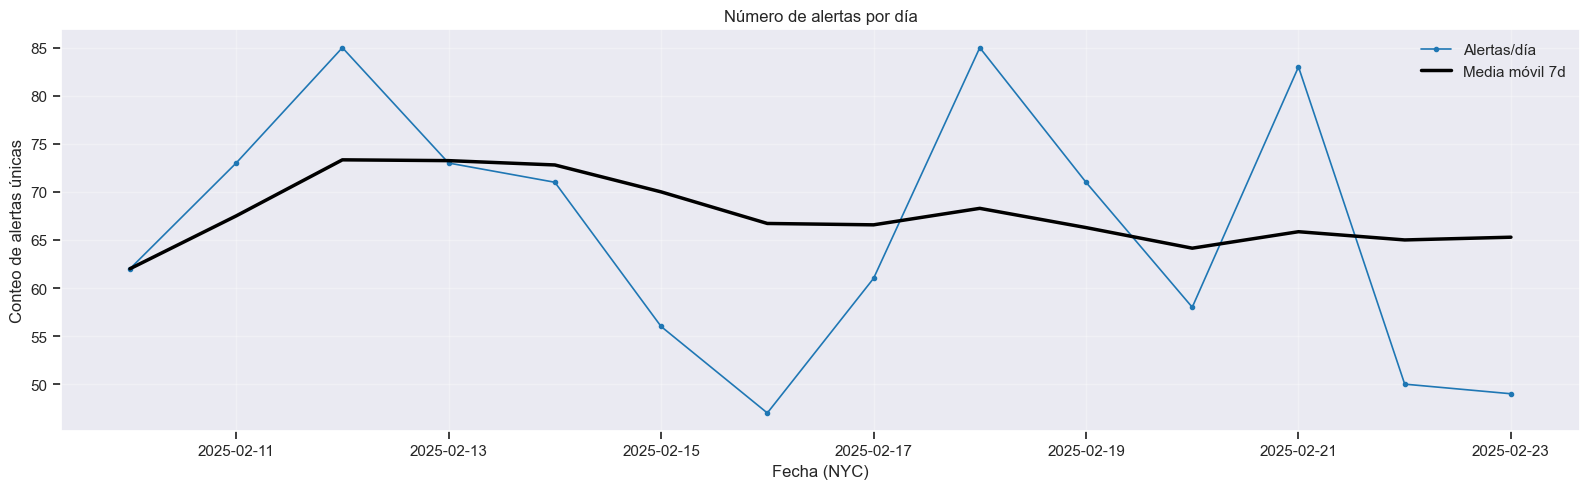

In [ ]:
daily_alerts = df_full.groupby('service_date')['event_id_active'].nunique().sort_index()
daily_alerts.index = pd.to_datetime(daily_alerts.index, errors='coerce')
daily_ma7 = daily_alerts.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_alerts.index, daily_alerts.values, marker='o', markersize=3, linewidth=1.2, label='Alertas/día')
ax.plot(daily_ma7.index, daily_ma7.values, linewidth=2.5, color='black', label='Media móvil 7d')
ax.set_title('Número de alertas por día')
ax.set_xlabel('Fecha (NYC)')
ax.set_ylabel('Conteo de alertas únicas')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

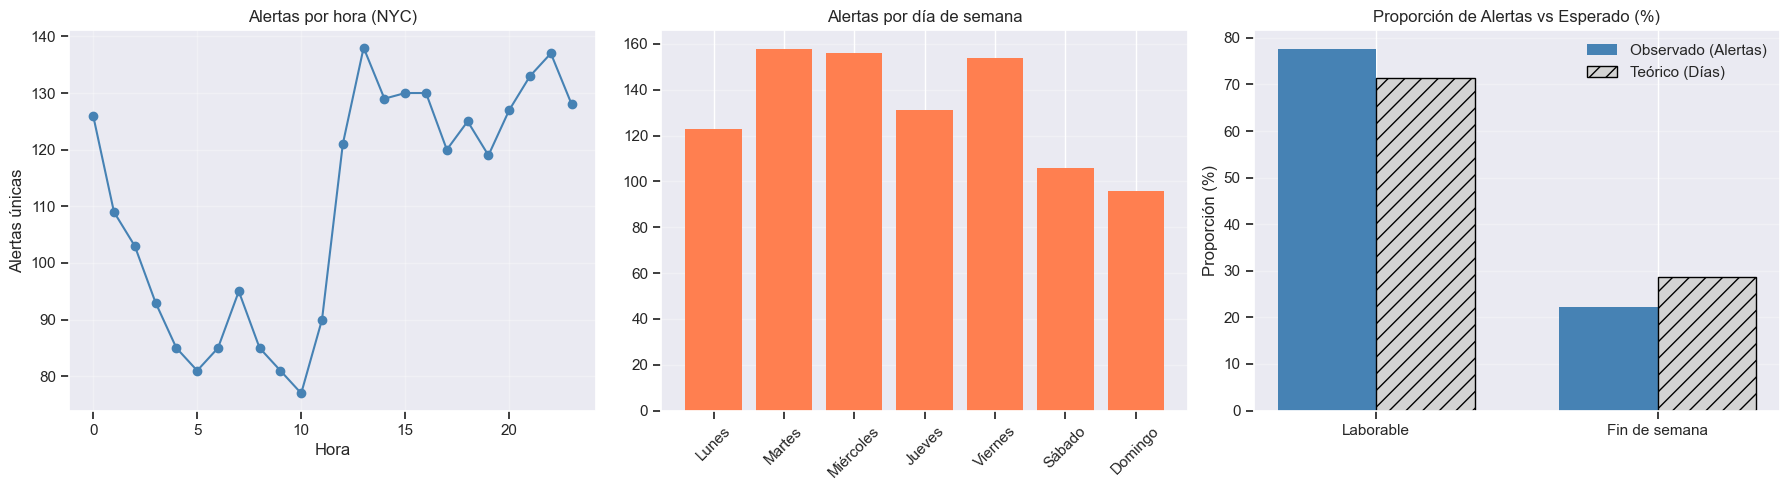

In [ ]:
dow_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}

hourly = df_full.groupby('hour')['event_id_active'].nunique().reindex(range(24), fill_value=0)
dow_counts = df_full.groupby('dow')['event_id_active'].nunique().reindex(range(7), fill_value=0)
weekend_comp = df_full.groupby('is_weekend')['event_id_active'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[0].set_title('Alertas por hora (NYC)')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Alertas únicas')
axes[0].grid(alpha=0.3)

axes[1].bar([dow_map[i] for i in dow_counts.index], dow_counts.values, color='coral')
axes[1].set_title('Alertas por día de semana')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

import numpy as np

labels = ['Laborable', 'Fin de semana']
vals = [weekend_comp.get(0, 0), weekend_comp.get(1, 0)]

# Calcular proporciones Observadas
total = sum(vals)
props_obs = [(v / total * 100) if total > 0 else 0 for v in vals]
# Definir proporciones Teóricas (5 días vs 2 días)
props_teo = [(5/7) * 100, (2/7) * 100]
# Configurar las posiciones para poner las barras lado a lado
x = np.arange(len(labels))
width = 0.35
# Dibujar el gráfico de barras agrupadas
axes[2].bar(x - width/2, props_obs, width, label='Observado (Alertas)', color='steelblue')
axes[2].bar(x + width/2, props_teo, width, label='Teórico (Días)', color='lightgray', edgecolor='black', hatch='//')
# Configurar textos y leyendas
axes[2].set_title('Proporción de Alertas vs Esperado (%)')
axes[2].set_ylabel('Proporción (%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

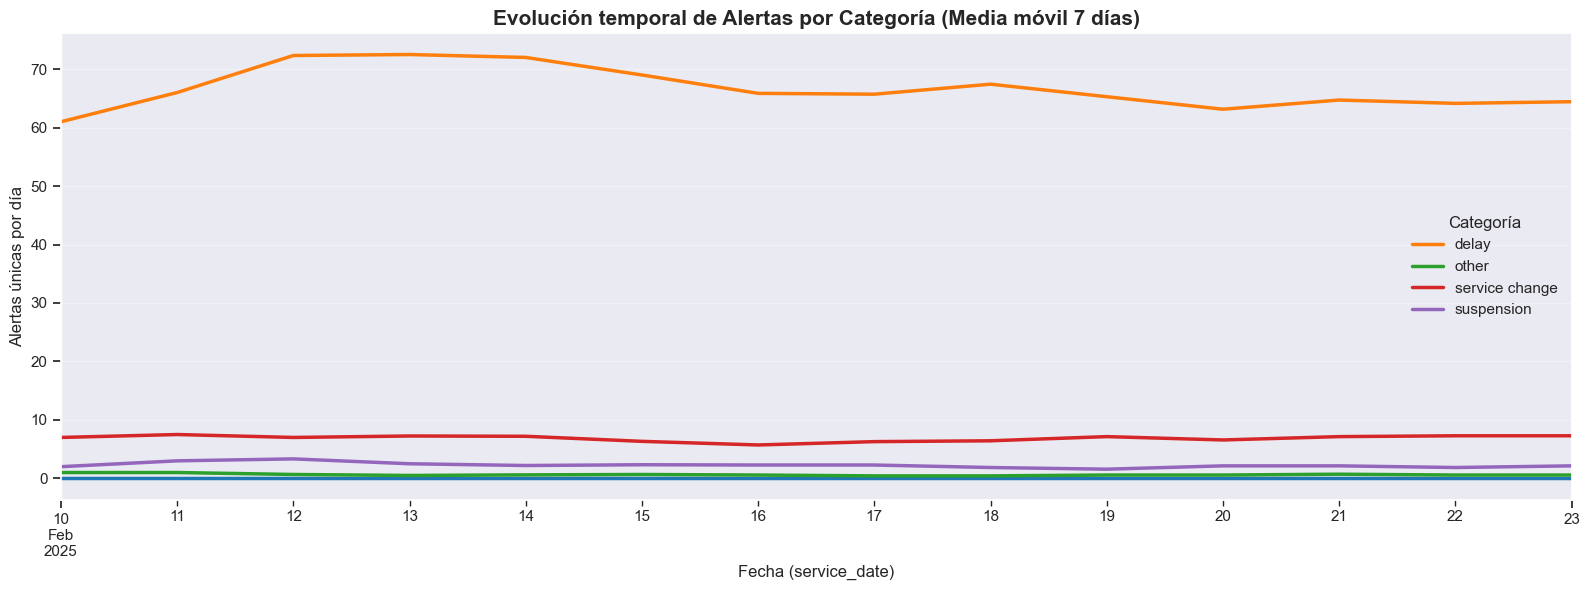

In [ ]:
# 1. Sacamos las 5 categorías principales de vuestro dataset real
top_categories = df_full['category_norm'].value_counts().head(5).index.tolist()

# 2. Agrupamos usando 'event_id_active' (que es el ID real) y 'service_date'
cat_time = (df_full[df_full['category_norm'].isin(top_categories)]
            .groupby(['service_date', 'category_norm'])['event_id_active']
            .nunique()
            .unstack(fill_value=0))

# Asegurarnos de que el índice es formato fecha
cat_time.index = pd.to_datetime(cat_time.index, errors='coerce')

# 3. Dibujamos una única gráfica clara y profesional (Media móvil de 7 días)
plt.figure(figsize=(16, 6))
cat_time.rolling(7, min_periods=1).mean().plot(linewidth=2.5, ax=plt.gca())

plt.title('Evolución temporal de Alertas por Categoría (Media móvil 7 días)', fontsize=15, fontweight='bold')
plt.ylabel('Alertas únicas por día', fontsize=12)
plt.xlabel('Fecha (service_date)', fontsize=12)
plt.legend(title='Categoría', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Conclusiones temporales
- La curva diaria y su media móvil de 7 días ayudan a separar ruido operativo de tendencias estructurales.
- Los patrones por hora y día revelan ventanas donde las alertas se concentran y pueden impactar más al servicio.
- La segmentación por `category` y `effect` permite identificar si los picos vienen por incidencias puntuales o por trabajos planificados.

In [ ]:
# 3.4 Control temporal: efecto condicional por hora y pico
if {'hour', 'delay_seconds', 'has_alert'}.issubset(df_full.columns):
    hour_effect = (
        df_full.groupby(['hour', 'has_alert'])['delay_seconds']
        .mean()
        .unstack(fill_value=np.nan)
        .rename(columns={0: 'no_alert', 1: 'with_alert'})
    )
    hour_effect['diff'] = hour_effect['with_alert'] - hour_effect['no_alert']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    hour_effect[['no_alert', 'with_alert']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Delay promedio por hora: con vs sin alertas')
    axes[0].set_xlabel('Hora')
    axes[0].set_ylabel('delay_seconds')
    axes[0].grid(alpha=0.3)

    axes[1].bar(hour_effect.index, hour_effect['diff'], color='slateblue')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Diferencia por hora (con - sin alerta)')
    axes[1].set_xlabel('Hora')
    axes[1].set_ylabel('Δ delay_seconds')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

if {'is_peak', 'delay_seconds', 'alert_active'}.issubset(df_full.columns):
    peak_effect = df_full.groupby(['is_peak', 'alert_active'])['delay_seconds'].mean().unstack(fill_value=np.nan)
    peak_effect = peak_effect.rename(index={0: 'off_peak', 1: 'peak'}, columns={0: 'no_alert', 1: 'with_alert'})
    peak_effect['diff'] = peak_effect['with_alert'] - peak_effect['no_alert']
    display(peak_effect.round(3))

alert_active,no_alert,with_alert,diff
is_peak,,,
off_peak,105.905,132.559,26.654
peak,71.515,75.004,3.489


### Conclusiones de relación alertas ↔ desempeño

- Si `mean_diff` en `delay_seconds` es positivo y consistente por hora/pico, hay evidencia descriptiva de asociación entre alertas y mayor retraso.
- Si `actual_headway_seconds` o `headway_ratio` aumentan con `has_alert`/`alert_count`, las alertas también se asocian con empeoramiento en regularidad de paso.
- Para delay futuro (`target_delay_*`), diferencias positivas sugieren persistencia del impacto más allá del instante actual.
- Importante: este análisis es correlacional (no causal). El siguiente paso es modelado controlado por línea, hora, día y estado previo (`lagged_delay_*`).

## 5) El desfase de comunicación (Latencia de la MTA)

**Contexto de negocio**
Si el retraso promedio ya venía creciendo antes de `timestamp_start`, entonces la publicación oficial llega tarde respecto al inicio real del problema. El minuto 0 representa el momento del aviso oficial, no necesariamente el inicio operativo de la congestión.

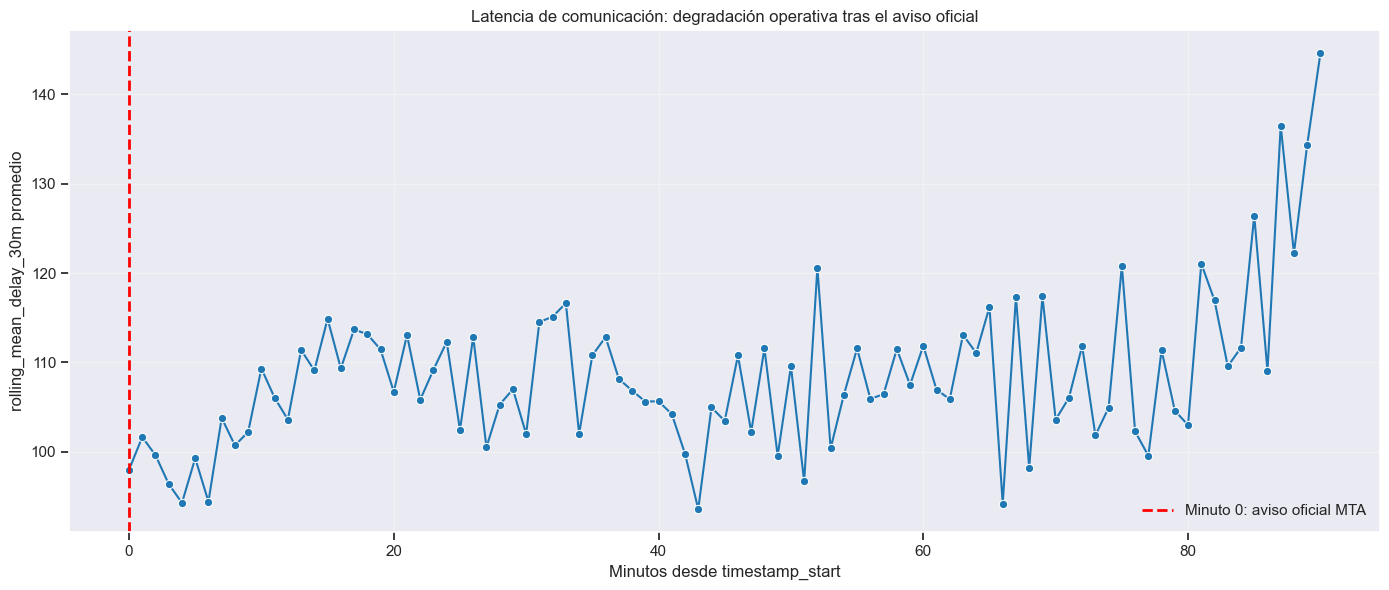

In [ ]:
# 5.1 Desfase de comunicación (Latencia MTA) usando df_full maestro
lat = df_full.copy()
lat['min_since_pub'] = pd.to_numeric(lat['min_minutes_since_publish'], errors='coerce')
lat = lat[(lat['alert_active'] == 1) & lat['min_since_pub'].between(0, 90, inclusive='both')].copy()

if 'is_unplanned_shock' in lat.columns:
    lat = lat[lat['is_unplanned_shock'] == 1].copy()

metric = 'rolling_mean_delay_30m' if 'rolling_mean_delay_30m' in lat.columns else 'delay_seconds'
lat['minute_from_start'] = lat['min_since_pub'].round().astype('Int64')
latency_curve = lat.groupby('minute_from_start', as_index=False)[metric].mean().sort_values('minute_from_start')

if latency_curve.empty:
    print('No hay observaciones suficientes para la latencia en [0, 90].')
else:
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=latency_curve, x='minute_from_start', y=metric, marker='o')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Minuto 0: aviso oficial MTA')
    plt.title('Latencia de comunicación: degradación operativa tras el aviso oficial')
    plt.xlabel('Minutos desde timestamp_start')
    plt.ylabel(f'{metric} promedio')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7) El radio de explosión (Propagación / Efecto contagio)

Una suspensión en una línea puede saturar estaciones compartidas y degradar la frecuencia de paso en líneas vecinas sin alerta directa. Aquí medimos ese contagio comparando su headway frente a una referencia normal.

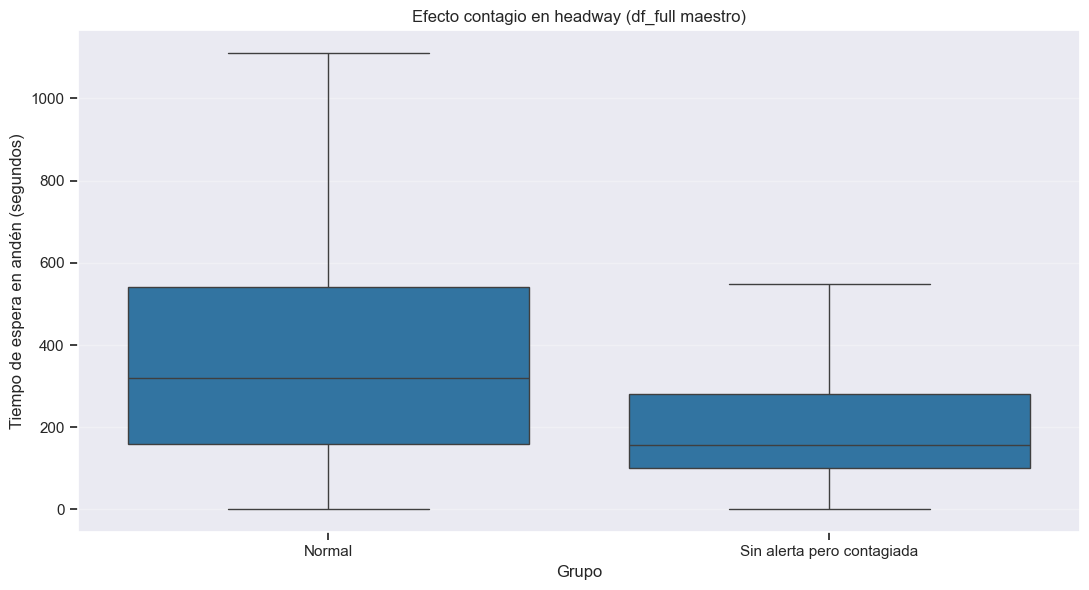

In [ ]:
# 7.1 Efecto contagio usando SOLO df_full
base_cols = ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds', 'alert_active', 'has_suspension_active']
missing = [c for c in base_cols if c not in df_full.columns]
if missing:
    print(f'No se puede calcular contagio. Faltan columnas: {missing}')
else:
    spread_df = df_full[base_cols].copy()
    spread_df['service_date'] = pd.to_datetime(spread_df['service_date'], errors='coerce')

    suspend_slots = (
        spread_df.loc[
            (spread_df['has_suspension_active'] == 1) & (spread_df['alert_active'] == 1) & spread_df['service_date'].notna(),
            ['service_date', 'hour', 'stop_id', 'route_id']
        ]
        .drop_duplicates()
        .rename(columns={'route_id': 'suspended_route_id'})
    )

    if suspend_slots.empty:
        print('No se detectaron franjas con suspensión activa.')
    else:
        other_lines = spread_df.merge(suspend_slots, on=['service_date', 'hour', 'stop_id'], how='inner')
        other_lines = other_lines.loc[other_lines['route_id'] != other_lines['suspended_route_id']].copy()

        exposed = other_lines.loc[
            (other_lines['alert_active'] == 0) & other_lines['actual_headway_seconds'].notna(),
            ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds']
        ].copy()
        exposed['grupo'] = 'Sin alerta pero contagiada'

        slot_keys = suspend_slots[['service_date', 'hour', 'stop_id']].drop_duplicates()
        baseline = spread_df.merge(slot_keys, on=['service_date', 'hour', 'stop_id'], how='left', indicator=True)
        baseline = baseline.loc[baseline['_merge'] == 'left_only'].copy()
        if not exposed.empty:
            baseline = baseline.loc[baseline['route_id'].isin(exposed['route_id'].unique())]
        baseline = baseline.loc[
            (baseline['alert_active'] == 0) & baseline['actual_headway_seconds'].notna(),
            ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds']
        ].copy()
        baseline['grupo'] = 'Normal'

        comp_headway = pd.concat([exposed, baseline], ignore_index=True)
        if comp_headway.empty or comp_headway['grupo'].nunique() < 2:
            print('No hay muestra suficiente para comparar contagio vs normal.')
        else:
            plt.figure(figsize=(11, 6))
            sns.boxplot(
                data=comp_headway,
                x='grupo',
                y='actual_headway_seconds',
                order=['Normal', 'Sin alerta pero contagiada'],
                showfliers=False
            )
            plt.title('Efecto contagio en headway (df_full maestro)')
            plt.xlabel('Grupo')
            plt.ylabel('Tiempo de espera en andén (segundos)')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

C:\Users\2alex\AppData\Local\Temp\ipykernel_25168\3129626528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\2alex\AppData\Local\Temp\ipykernel_25168\3129626528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.1f}%'.format(x*100) for x in plt.gca().get_yticks()])


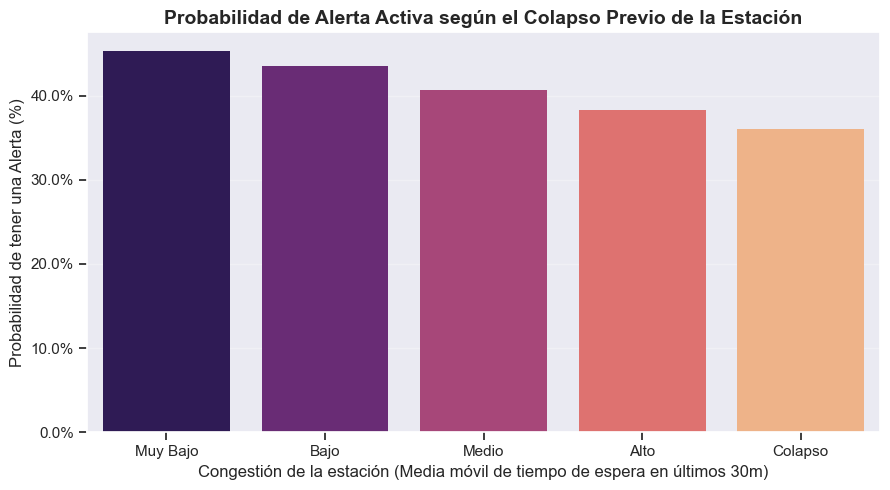

In [ ]:
# Hacemos grupos (bins) del Headway acumulado en la última media hora
df_full['headway_rolling_binned'] = pd.qcut(df_full['rolling_mean_headway_30m'].dropna(), q=5, labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Colapso'])

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_full.dropna(subset=['headway_rolling_binned']), 
    x='headway_rolling_binned', 
    y='alert_active', # Probabilidad de que haya una alerta
    palette='magma',
    errorbar=None
)
plt.title('Probabilidad de Alerta Activa según el Colapso Previo de la Estación', fontsize=14, fontweight='bold')
plt.xlabel('Congestión de la estación (Media móvil de tiempo de espera en últimos 30m)', fontsize=12)
plt.ylabel('Probabilidad de tener una Alerta (%)', fontsize=12)
plt.gca().set_yticklabels(['{:.1f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\2alex\AppData\Local\Temp\ipykernel_25168\566889535.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


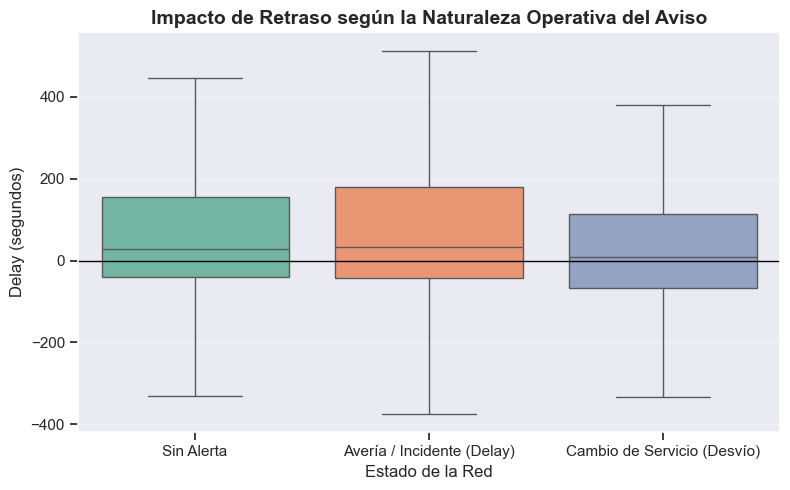

In [ ]:
# Creamos una columna para diferenciar el tipo exacto
df_full['tipo_incidencia'] = 'Sin Alerta'
df_full.loc[df_full['has_service_change_active'] == 1, 'tipo_incidencia'] = 'Cambio de Servicio (Desvío)'
df_full.loc[df_full['has_delay_alert_active'] == 1, 'tipo_incidencia'] = 'Avería / Incidente (Delay)'

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_full, 
    x='tipo_incidencia', 
    y='delay_seconds', 
    palette='Set2',
    showfliers=False # Quitamos los extremos brutales para ver las cajas
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Impacto de Retraso según la Naturaleza Operativa del Aviso', fontsize=14, fontweight='bold')
plt.xlabel('Estado de la Red', fontsize=12)
plt.ylabel('Delay (segundos)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9) Latencia operativa post-publicación

> Todas las métricas se calculan sobre `df_full` y `min_minutes_since_publish`, sin merges adicionales.

c:\Users\2alex\c2526-R5\.venv\Lib\site-packages\pandas\core\arrays\timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


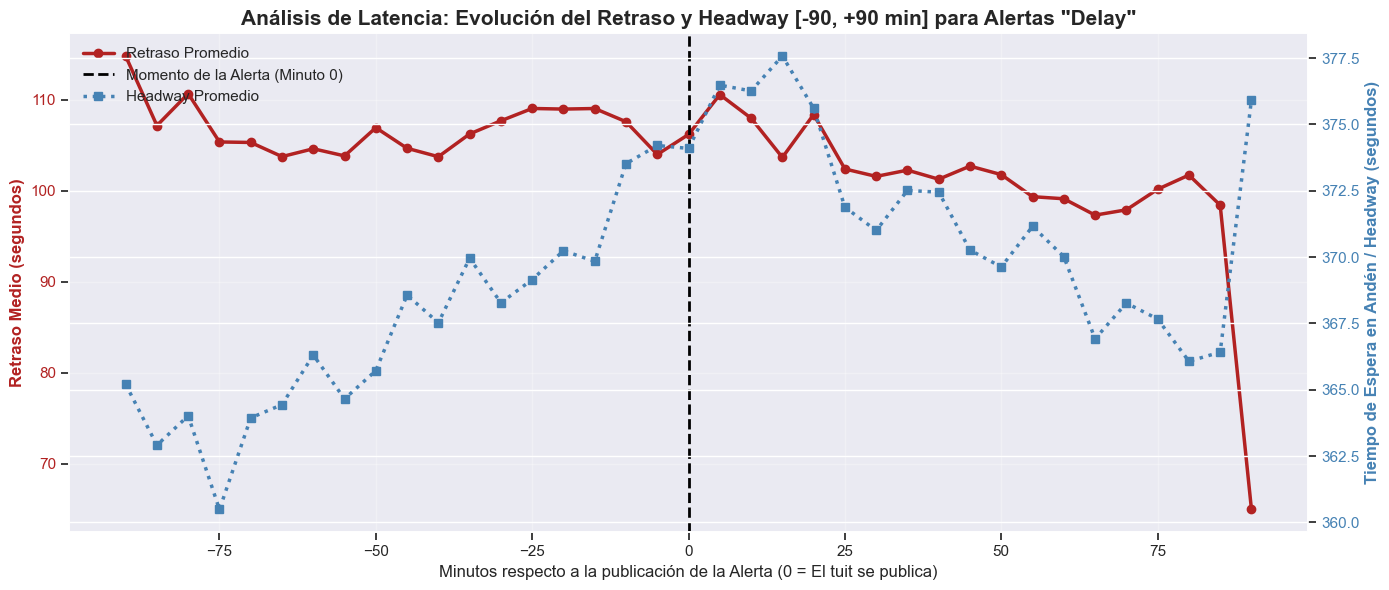

In [ ]:
# Cogemos el GTFS y las alertas base
gtfs_plot = df_gtfs[['route_id', 'service_date', 'actual_seconds', 'delay_seconds', 'actual_headway_seconds']].copy()
alerts_plot = df_alerts[df_alerts['category'] == 'Delay'][['lines', 'timestamp_start', 'service_date']].copy()

# Calculamos la hora de llegada del tren
gtfs_plot['arrival_dt'] = pd.to_datetime(gtfs_plot['service_date']) + pd.to_timedelta(gtfs_plot['actual_seconds'], unit='s')
gtfs_plot['service_date'] = gtfs_plot['service_date'].astype(str)

# Limpiamos las rutas en GTFS
gtfs_plot['route_id'] = gtfs_plot['route_id'].astype(str).str.replace(r"[\[\]'\"\s]", "", regex=True).str.upper()

# Explotamos las líneas de las alertas (de "A,C" a "A" y "C")
alerts_plot['lines'] = alerts_plot['lines'].astype(str).str.replace(r"[\[\]'\"\s]", "", regex=True).str.upper()
alerts_plot['route_id'] = alerts_plot['lines'].str.split(',')
alerts_plot = alerts_plot.explode('route_id')
alerts_plot['service_date'] = alerts_plot['service_date'].astype(str)

# Cruzamos por ruta y día
df_cruce = pd.merge(gtfs_plot, alerts_plot[['route_id', 'service_date', 'timestamp_start']], on=['route_id', 'service_date'], how='inner')

# Calculamos los minutos relativos: Negativo = Antes del aviso | Positivo = Después del aviso
df_cruce['minutos_relativos'] = (df_cruce['arrival_dt'] - pd.to_datetime(df_cruce['timestamp_start']).dt.tz_localize(None)).dt.total_seconds() / 60.0

# Filtramos estrictamente la ventana de -90 a +90
df_cruce = df_cruce[(df_cruce['minutos_relativos'] >= -90) & (df_cruce['minutos_relativos'] <= 90)].copy()

# Binning cada 5 minutos
df_cruce['minutos_bin'] = (np.floor(df_cruce['minutos_relativos'] / 5) * 5)

# Agrupamos
resumen = df_cruce.groupby('minutos_bin')[['delay_seconds', 'actual_headway_seconds']].mean().reset_index()

# Gráfica
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Eje 1 (Izquierdo): Delay en Rojo ---
color1 = 'firebrick'
ax1.set_xlabel('Minutos respecto a la publicación de la Alerta (0 = El tuit se publica)', fontsize=12)
ax1.set_ylabel('Retraso Medio (segundos)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(resumen['minutos_bin'], resumen['delay_seconds'], color=color1, marker='o', linewidth=2.5, label='Retraso Promedio')
ax1.tick_params(axis='y', labelcolor=color1)

# Línea central marcando el momento exacto del aviso
ax1.axvline(0, color='black', linestyle='--', linewidth=2, label='Momento de la Alerta (Minuto 0)')

# --- Eje 2 (Derecho): Headway en Azul ---
ax2 = ax1.twinx()  
color2 = 'steelblue'
ax2.set_ylabel('Tiempo de Espera en Andén / Headway (segundos)', color=color2, fontsize=12, fontweight='bold')  
ax2.plot(resumen['minutos_bin'], resumen['actual_headway_seconds'], color=color2, marker='s', linewidth=2.5, linestyle=':', label='Headway Promedio')
ax2.tick_params(axis='y', labelcolor=color2)

# Configuración final
plt.title('Análisis de Latencia: Evolución del Retraso y Headway [-90, +90 min] para Alertas "Delay"', fontsize=15, fontweight='bold')
ax1.grid(alpha=0.3)
fig.tight_layout()

# Juntar las leyendas de ambos ejes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

## 10) Indicios tempranos previos a la publicación

Ventana de análisis: `0 a 60` minutos antes del aviso oficial, usando `min_minutes_since_publish` y features rolling del dataset maestro.

In [ ]:
# Extraemos y limpiamos las alertas
alerts_plot = df_alerts_exp.copy()
alerts_plot['lines'] = alerts_plot['lines'].astype(str).str.replace(r"[\[\]'\"\s]", "", regex=True).str.upper()
alerts_plot['route_id'] = alerts_plot['lines'].str.split(',')
alerts_plot = alerts_plot.explode('route_id')

# Clasificamos usando el texto original (description) o la categoría
texto_alerta = alerts_plot['category'].fillna('') + " " + alerts_plot['description'].fillna('') + " " + alerts_plot['text_snippet'].fillna('')

mask_planned = texto_alerta.str.contains('planned work|maintenance|weekend|service change', case=False, regex=True)
mask_shock = texto_alerta.str.contains('signal|sick|police|unauthorized|delay|suspension|investigation', case=False, regex=True)

alerts_plot['incident_group'] = 'Otro'
alerts_plot.loc[mask_planned, 'incident_group'] = 'Trabajo planificado'
alerts_plot.loc[mask_shock & ~mask_planned, 'incident_group'] = 'Shock no planificado'

# Limpieza final de fechas y rutas
alerts_plot['timestamp_start'] = pd.to_datetime(alerts_plot['timestamp_start']).dt.tz_localize(None)
alerts_plot['service_date'] = alerts_plot['timestamp_start'].dt.date.astype(str)
alerts_plot = alerts_plot[alerts_plot['incident_group'] != 'Otro'] # Nos quedamos solo con lo importante

# =======================================================
# 2. CRUZAR CON EL GTFS (Solo 60 min previos)
# =======================================================
# Sacamos los datos de GTFS
gtfs_plot = df_gtfs[['route_id', 'service_date', 'actual_seconds', 'actual_headway_seconds', 'delay_seconds']].copy()
gtfs_plot['route_id'] = gtfs_plot['route_id'].astype(str).str.replace(r"[\[\]'\"\s]", "", regex=True).str.upper()
gtfs_plot['arrival_dt'] = pd.to_datetime(gtfs_plot['service_date']) + pd.to_timedelta(gtfs_plot['actual_seconds'], unit='s')
gtfs_plot['service_date'] = gtfs_plot['service_date'].astype(str)

# Cruce
df_cruce = pd.merge(gtfs_plot, alerts_plot[['route_id', 'service_date', 'timestamp_start', 'incident_group']], on=['route_id', 'service_date'], how='inner')

# Calcular minutos previos (-60 a 0)
df_cruce['minutos_relativos'] = (df_cruce['arrival_dt'] - df_cruce['timestamp_start']).dt.total_seconds() / 60.0

# Filtramos la hora previa y agrupamos cada 5 mins
df_cruce = df_cruce[(df_cruce['minutos_relativos'] >= -60) & (df_cruce['minutos_relativos'] <= 0)].copy()
df_cruce['minutos_bin'] = (np.floor(df_cruce['minutos_relativos'] / 5) * 5)

resumen = df_cruce.groupby(['minutos_bin', 'incident_group'], as_index=False)['actual_headway_seconds'].mean()

# =======================================================
# 3. DIBUJAR LA GRÁFICA
# =======================================================
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=resumen,
    x='minutos_bin',
    y='actual_headway_seconds',
    hue='incident_group',
    marker='o',
    linewidth=2.5,
    palette=['darkorange', 'steelblue'] 
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.8, label='Publicación alerta (min 0)')
plt.title('Indicios Tempranos: Deterioro del tiempo de espera según el tipo de incidencia', fontsize=14, fontweight='bold')
plt.xlabel('Minutos previos a la publicación oficial (El tiempo avanza hacia el 0)')
plt.ylabel('Tiempo de espera en andén (segundos)')
plt.grid(alpha=0.3)
plt.legend(title='Naturaleza del Evento')
plt.tight_layout()
plt.show()

NameError: name 'df_alerts' is not defined

## 11) Firmas predictivas tempranas

> Objetivo: medir aceleración del retraso (primera derivada) y caída de throughput (`n_trains_30m`) antes de alertas de suspensión.

In [10]:
# 11.1 Preparación de ventana previa usando SOLO df_full maestro
if 'minutes_relative_to_publish' not in df_full.columns:
    raise ValueError('df_full maestro no contiene minutes_relative_to_publish. Reejecuta la celda 2.x Pipeline Maestro.')

df_prev = df_full.copy()
df_prev['min_rel_alerta_firmado'] = pd.to_numeric(df_prev['minutes_relative_to_publish'], errors='coerce')
df_prev = df_prev[df_prev['min_rel_alerta_firmado'].between(-60, 0, inclusive='both')].copy()
df_prev['minutos_previos'] = -df_prev['min_rel_alerta_firmado']
df_prev['minutos_previos_bin'] = (np.floor(df_prev['minutos_previos'] / 5) * 5).astype('Int64')

need_cols = ['stop_id', 'rolling_mean_delay_30m', 'n_trains_30m', 'event_id_active']
missing = [c for c in need_cols if c not in df_prev.columns]
if missing:
    print(f'Advertencia: faltan columnas en df_full para firmas tempranas: {missing}')

print('Shape ventana previa:', df_prev.shape)
display(df_prev[['route_id', 'service_date', 'arrival_dt', 'min_rel_alerta_firmado', 'minutos_previos', 'minutos_previos_bin']].head())

Shape ventana previa: (219382, 64)


,route_id,service_date,arrival_dt,min_rel_alerta_firmado,minutos_previos,minutos_previos_bin
14284,2,2025-02-10,2025-02-10 05:36:05,-58.916667,58.916667,55
14368,2,2025-02-10,2025-02-10 05:37:20,-57.666667,57.666667,55
14475,2,2025-02-10,2025-02-10 05:38:55,-56.083333,56.083333,55
14540,2,2025-02-10,2025-02-10 05:39:59,-55.016667,55.016667,55
14660,2,2025-02-10,2025-02-10 05:41:19,-53.683333,53.683333,50


### 11.2 Gráfica 1 — Velocidad de Degradación (Primera Derivada)

En lugar de mirar el retraso estático, medimos la **aceleración del problema**: cuántos segundos de retraso se agregan por cada tren que pasa por estación.

- Se ordena por `stop_id` y `arrival_dt`.
- Se calcula `tasa_crecimiento_delay` como `diff()` de `rolling_mean_delay_30m` por estación.
- Se agregan medias por bloque de 5 minutos previos.
- El eje X se invierte para leer la cuenta regresiva hacia el aviso oficial (60 → 0).

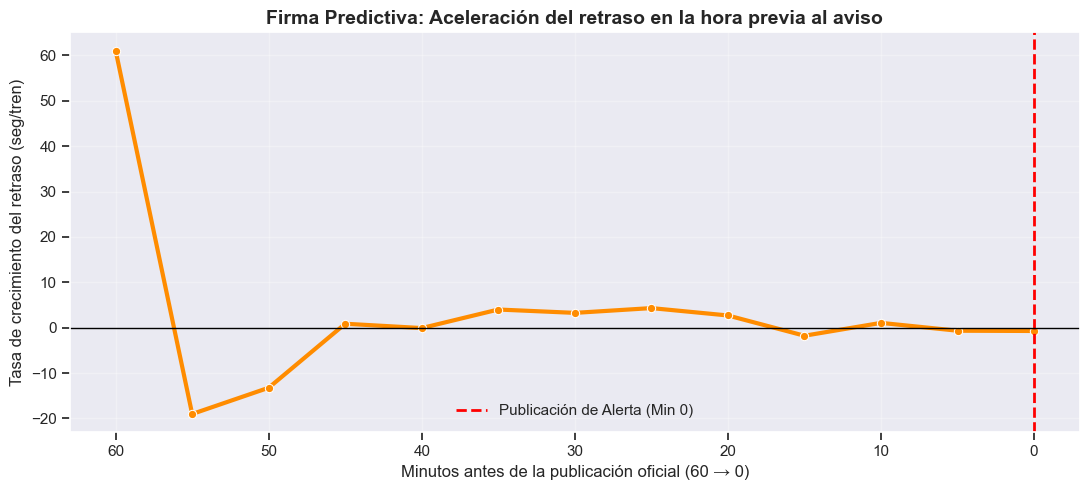

In [11]:
# 11.2 Primera derivada: corrección matemática (groupby event_id + stop_id)
df_derivada = df_prev.copy()
df_derivada = df_derivada.sort_values(['event_id_active', 'stop_id', 'arrival_dt'])

df_derivada['tasa_crecimiento_delay'] = (
    df_derivada.groupby(['event_id_active', 'stop_id'], dropna=False)['rolling_mean_delay_30m']
    .diff()
)
df_derivada['tasa_crecimiento_delay'] = pd.to_numeric(df_derivada['tasa_crecimiento_delay'], errors='coerce')
df_derivada.loc[~np.isfinite(df_derivada['tasa_crecimiento_delay']), 'tasa_crecimiento_delay'] = np.nan

curve_deriv = (
    df_derivada.groupby('minutos_previos_bin', as_index=False)['tasa_crecimiento_delay']
    .mean()
    .sort_values('minutos_previos_bin')
)

if curve_deriv['tasa_crecimiento_delay'].dropna().empty:
    print('No hay datos suficientes para la primera derivada en [0, 60].')
else:
    plt.figure(figsize=(11, 5))
    sns.lineplot(
        data=curve_deriv,
        x='minutos_previos_bin',
        y='tasa_crecimiento_delay',
        color='darkorange',
        linewidth=3,
        marker='o',
        errorbar=None
    )
    plt.gca().invert_xaxis()
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Publicación de Alerta (Min 0)')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Firma Predictiva: Aceleración del retraso en la hora previa al aviso', fontsize=14, fontweight='bold')
    plt.xlabel('Minutos antes de la publicación oficial (60 → 0)', fontsize=12)
    plt.ylabel('Tasa de crecimiento del retraso (seg/tren)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 11.3 Gráfica 2 — Apagón de Rendimiento (Caída de Throughput)

Ahora enfocamos alertas graves (`category == 'Suspension'`) y medimos si el volumen operativo (`n_trains_30m`) cae antes de que salga el aviso oficial.

- Se filtra la ventana previa para `Suspension`.
- Se grafica la media de `n_trains_30m` por bloque de 5 minutos.
- El eje X también se invierte para leer deterioro en cuenta regresiva al aviso.

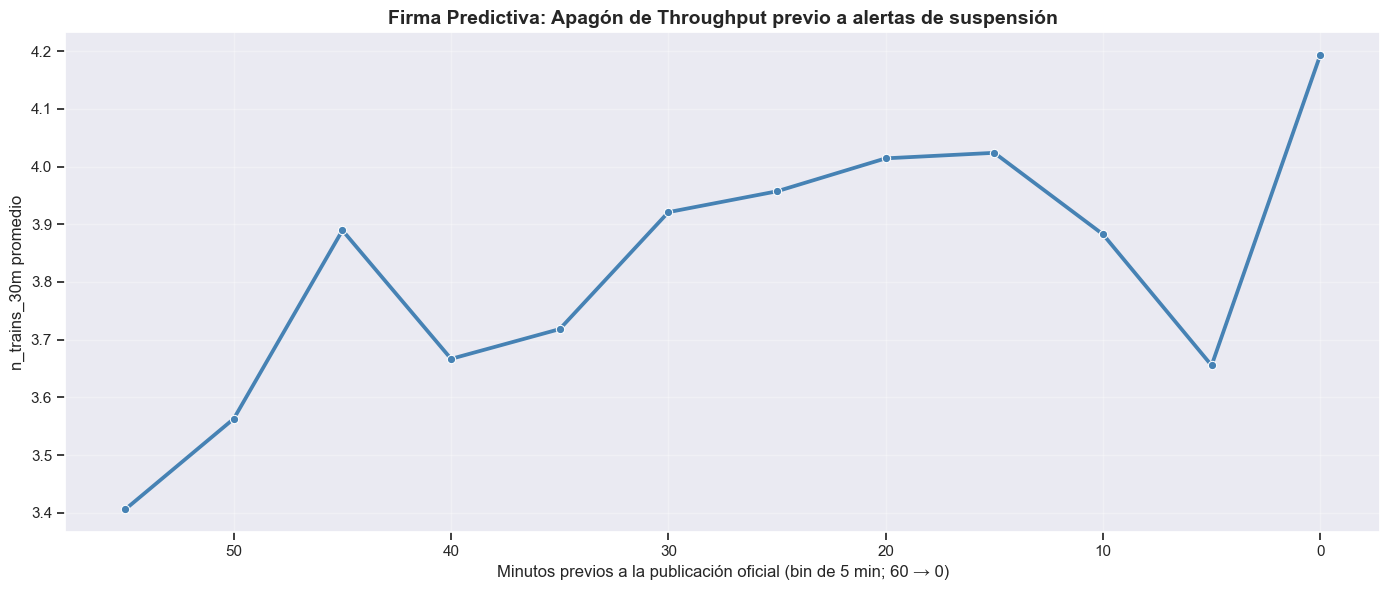

,minutos_previos_bin,n_trains_30m
0,0,4.193431
1,5,3.655319
2,10,3.882609
3,15,4.023923
4,20,4.014354
5,25,3.957219
6,30,3.921053
7,35,3.718310
8,40,3.666667
9,45,3.889571


In [12]:
# 11.3 Throughput: media de n_trains_30m por bins temporales (df_full maestro)
df_susp = df_prev.copy()
if 'next_is_suspension_alert' in df_susp.columns:
    df_susp = df_susp[df_susp['next_is_suspension_alert'] == 1].copy()
elif 'has_suspension_active' in df_susp.columns:
    df_susp = df_susp[df_susp['has_suspension_active'] == 1].copy()
elif 'category' in df_susp.columns:
    df_susp = df_susp[df_susp['category'].astype(str).str.strip().str.lower() == 'suspension'].copy()
else:
    df_susp = df_susp.iloc[0:0].copy()

df_susp['n_trains_30m'] = pd.to_numeric(df_susp['n_trains_30m'], errors='coerce')
curve_throughput = (
    df_susp.groupby('minutos_previos_bin', as_index=False)['n_trains_30m']
    .mean()
    .sort_values('minutos_previos_bin')
)

if curve_throughput['n_trains_30m'].dropna().empty:
    print("No hay muestra suficiente para alertas de suspensión en ventana [0, 60].")
else:
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=curve_throughput,
        x='minutos_previos_bin',
        y='n_trains_30m',
        marker='o',
        linewidth=2.7,
        color='steelblue'
    )
    plt.gca().invert_xaxis()
    plt.title('Firma Predictiva: Apagón de Throughput previo a alertas de suspensión', fontsize=14, fontweight='bold')
    plt.xlabel('Minutos previos a la publicación oficial (bin de 5 min; 60 → 0)')
    plt.ylabel('n_trains_30m promedio')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

display(curve_throughput.head(15))

## 12) Curva de recuperación de la red (resiliencia post-evento)

Medimos cuánto tarda la red en normalizarse tras un evento, en la ventana de 0 a 120 minutos posteriores a la publicación.

In [13]:
# 12.1 Curva de recuperación (0 a 120 min) con fallback de delta
rec = df_full.copy()

# Si no existe delta_delay_30m, lo derivamos en caliente
if 'delta_delay_30m' not in rec.columns:
    if 'rolling_mean_delay_30m' in rec.columns:
        rec = rec.sort_values(['stop_id', 'arrival_dt']).copy()
        rec['delta_delay_30m'] = rec.groupby('stop_id', dropna=False)['rolling_mean_delay_30m'].diff()
    elif 'delay_seconds' in rec.columns:
        rec = rec.sort_values(['stop_id', 'arrival_dt']).copy()
        rec['delta_delay_30m'] = rec.groupby('stop_id', dropna=False)['delay_seconds'].diff()
    else:
        raise ValueError('No se puede construir delta_delay_30m (faltan rolling_mean_delay_30m y delay_seconds).')

rec['post_min'] = pd.to_numeric(rec['min_minutes_since_publish'], errors='coerce')
rec = rec[rec['post_min'].between(0, 120, inclusive='both')].copy()

if 'is_unplanned_shock' in rec.columns:
    rec = rec[rec['is_unplanned_shock'] == 1].copy()

rec = rec[rec['delta_delay_30m'].notna()].copy()
rec['post_bin_5m'] = (np.floor(rec['post_min'] / 5) * 5).astype('Int64')
recovery_curve = (
    rec.groupby('post_bin_5m', as_index=False)['delta_delay_30m']
    .mean()
    .sort_values('post_bin_5m')
)

if recovery_curve.empty:
    print('No hay datos suficientes para curva de recuperación en [0, 120].')
else:
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=recovery_curve,
        x='post_bin_5m',
        y='delta_delay_30m',
        marker='o',
        linewidth=2.7,
        color='seagreen'
    )
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.title('Curva de Recuperación: inercia post-evento (0 a 120 min)', fontsize=14, fontweight='bold')
    plt.xlabel('Minutos posteriores al evento (bin 5 min)')
    plt.ylabel('delta_delay_30m promedio')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

display(recovery_curve.head(20))

KeyboardInterrupt: 

### Lectura de la curva de recuperación

- Cruce por debajo de cero en `delta_delay_30m` sugiere inicio de normalización.
- Meseta positiva prolongada implica inercia operacional tras la incidencia.
- Comparar shocks planificados vs no planificados permite priorizar acciones de control.